# Notebook 06 — Evaluation & Fehleranalyse

Vergleicht Scratch CNN und ResNet-18 auf dem **Test-Set** (unseen during training).

**Inhalt:**
1. Beide Modelle auf Test-Set evaluieren
2. Confusion Matrix (10×10 Heatmap) für beide Modelle
3. Per-Class Precision / Recall / F1
4. Vergleichstabelle: Accuracy, Parameter, Training-Zeit
5. Fehleranalyse: 10 falsch klassifizierte Cover
6. Diskussion: Wo verwechselt das Modell — und warum?

In [17]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.models as tv_models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from dataset import AlbumCoverDataset, GENRES, IDX_TO_GENRE  # noqa: E402

SPLITS_DIR      = ROOT / "data" / "splits" / "random"
CHECKPOINTS_DIR = ROOT / "data" / "checkpoints"

device = (
    torch.device("mps")  if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Device: {device}")

Device: mps


## Modelle laden

In [18]:
# ── Scratch CNN ────────────────────────────────────────────────────────────
class ScratchCNN(nn.Module):
    def __init__(self, dropout: float = 0.5) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,   32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout),
            nn.Linear(256, 10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # type: ignore[override]
        return self.classifier(self.features(x))


scratch_ckpt = torch.load(
    CHECKPOINTS_DIR / "scratch_best.pt",
    map_location=device,
    weights_only=True,
)
# Dropout-Wert aus Checkpoint-Metadata — fall back to 0.5 wenn nicht gespeichert
scratch_model = ScratchCNN(dropout=scratch_ckpt.get("dropout", 0.5)).to(device)
scratch_model.load_state_dict(scratch_ckpt["state_dict"])
scratch_model.eval()
print(f"Scratch CNN geladen  (epoch={scratch_ckpt['epoch']}, val_acc={scratch_ckpt['val_acc']:.3f})")

# ── ResNet-18 ──────────────────────────────────────────────────────────────
resnet_model = tv_models.resnet18(weights=None)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)
resnet_ckpt = torch.load(
    CHECKPOINTS_DIR / "resnet18_best.pt",
    map_location=device,
    weights_only=True,
)
resnet_model.load_state_dict(resnet_ckpt["state_dict"])
resnet_model = resnet_model.to(device)
resnet_model.eval()
print(f"ResNet-18 geladen    (epoch={resnet_ckpt['epoch']}, val_acc={resnet_ckpt['val_acc']:.3f})")

Scratch CNN geladen  (epoch=19, val_acc=0.277)
ResNet-18 geladen    (epoch=20, val_acc=0.448)


## Test-DataLoader

In [19]:
pin         = device.type == "cuda"   # pin_memory nur sinnvoll bei CUDA
num_workers = 0                        # 0 = sicher in Notebooks auf macOS (MPS/fork quirks)

test_loader = DataLoader(
    AlbumCoverDataset(SPLITS_DIR / "test.csv", "test"),
    batch_size=64, shuffle=False,
    num_workers=num_workers, pin_memory=pin,
)
print(f"Test batches: {len(test_loader)}")

Test batches: 6


## Hilfsfunktion: Predictions sammeln

In [20]:
def get_predictions(
    model: nn.Module,
    loader: DataLoader,
) -> tuple[list[int], list[int], list[float]]:
    """Gibt (y_true, y_pred, confidences) zurück."""
    y_true, y_pred, confs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            probs     = torch.softmax(out, dim=1)
            preds     = out.argmax(1).cpu().tolist()
            conf      = probs.max(1).values.cpu().tolist()
            y_true.extend(labels.tolist())
            y_pred.extend(preds)
            confs.extend(conf)
    return y_true, y_pred, confs


scratch_true, scratch_pred, scratch_conf = get_predictions(scratch_model, test_loader)
resnet_true,  resnet_pred,  resnet_conf  = get_predictions(resnet_model,  test_loader)

scratch_acc = sum(t == p for t, p in zip(scratch_true, scratch_pred)) / len(scratch_true)
resnet_acc  = sum(t == p for t, p in zip(resnet_true,  resnet_pred))  / len(resnet_true)

print(f"Scratch CNN  Test-Accuracy: {scratch_acc:.3f}")
print(f"ResNet-18    Test-Accuracy: {resnet_acc:.3f}")

Scratch CNN  Test-Accuracy: 0.261
ResNet-18    Test-Accuracy: 0.428


## Confusion Matrices

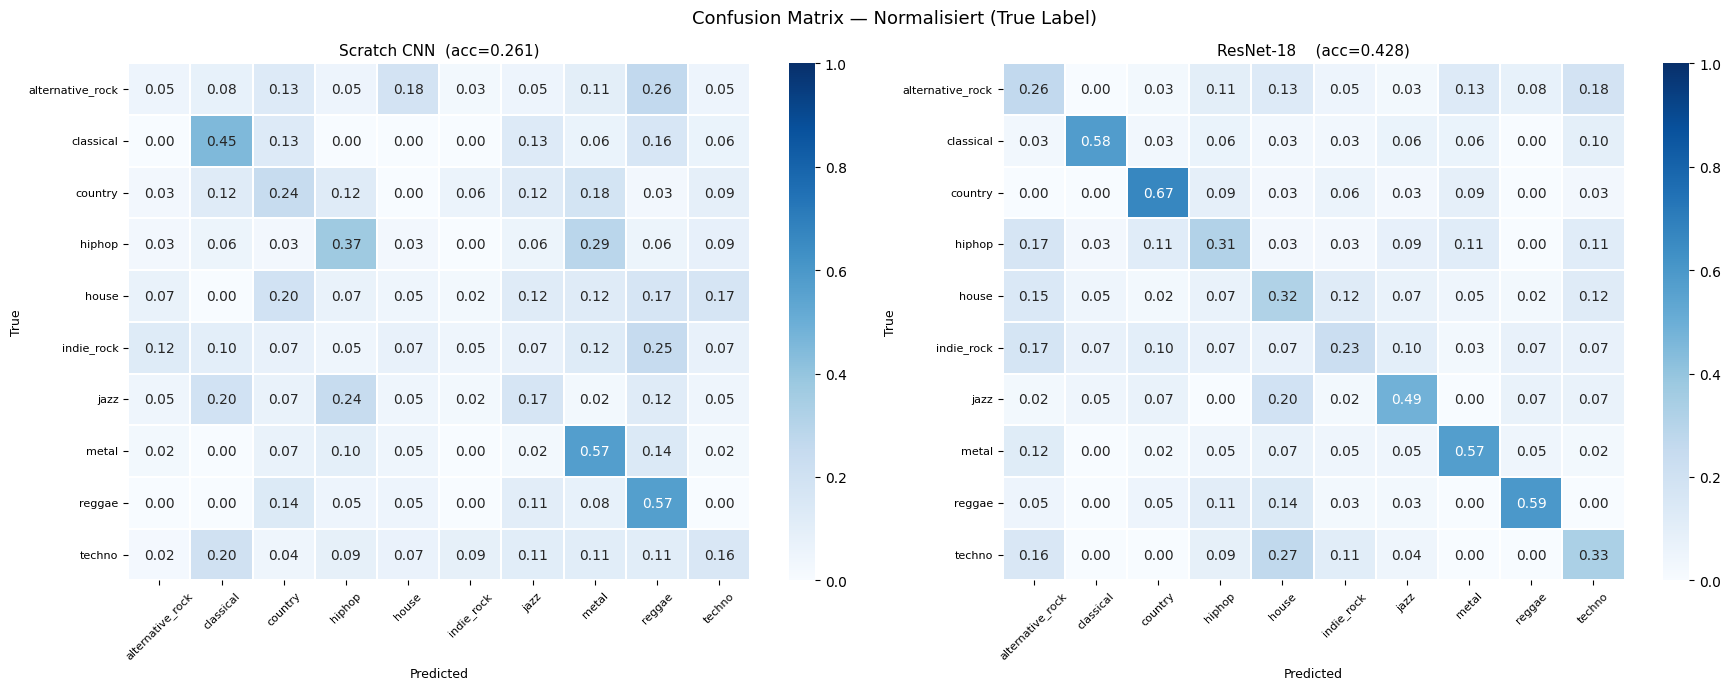

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, y_true, y_pred, title in [
    (axes[0], scratch_true, scratch_pred, f"Scratch CNN  (acc={scratch_acc:.3f})"),
    (axes[1], resnet_true,  resnet_pred,  f"ResNet-18    (acc={resnet_acc:.3f})"),
]:
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    sns.heatmap(
        cm,
        annot=True, fmt=".2f",
        xticklabels=GENRES, yticklabels=GENRES,
        cmap="Blues", vmin=0, vmax=1,
        ax=ax, linewidths=0.3,
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True", fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.suptitle("Confusion Matrix — Normalisiert (True Label)", fontsize=13)
plt.tight_layout()
plt.show()

## Per-Class Metriken

In [22]:
print("═" * 60)
print("Scratch CNN — Classification Report")
print("═" * 60)
print(classification_report(scratch_true, scratch_pred, target_names=GENRES, digits=3))

print("═" * 60)
print("ResNet-18 — Classification Report")
print("═" * 60)
print(classification_report(resnet_true, resnet_pred, target_names=GENRES, digits=3))

════════════════════════════════════════════════════════════
Scratch CNN — Classification Report
════════════════════════════════════════════════════════════
                  precision    recall  f1-score   support

alternative_rock      0.125     0.053     0.074        38
       classical      0.318     0.452     0.373        31
         country      0.190     0.242     0.213        33
          hiphop      0.295     0.371     0.329        35
           house      0.091     0.049     0.063        41
      indie_rock      0.182     0.050     0.078        40
            jazz      0.189     0.171     0.179        41
           metal      0.369     0.571     0.449        42
          reggae      0.292     0.568     0.385        37
          techno      0.233     0.156     0.187        45

        accuracy                          0.261       383
       macro avg      0.229     0.268     0.233       383
    weighted avg      0.227     0.261     0.229       383

═══════════════════════════

## Vergleichstabelle

In [23]:
def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters())


comparison = pd.DataFrame([
    {
        "Modell":          "Scratch CNN",
        "Test-Accuracy":   f"{scratch_acc:.3f}",
        "Parameter":       f"{count_params(scratch_model):,}",
        "Val-Acc (best)":  f"{scratch_ckpt['val_acc']:.3f}",
        "Epochs (best)":   scratch_ckpt["epoch"],
    },
    {
        "Modell":          "ResNet-18",
        "Test-Accuracy":   f"{resnet_acc:.3f}",
        "Parameter":       f"{count_params(resnet_model):,}",
        "Val-Acc (best)":  f"{resnet_ckpt['val_acc']:.3f}",
        "Epochs (best)":   resnet_ckpt["epoch"],
    },
])
print(comparison.to_string(index=False))

     Modell Test-Accuracy  Parameter Val-Acc (best)  Epochs (best)
Scratch CNN         0.261    391,946          0.277             19
  ResNet-18         0.428 11,181,642          0.448             20


## Fehleranalyse — 10 falsch klassifizierte Cover (ResNet-18)

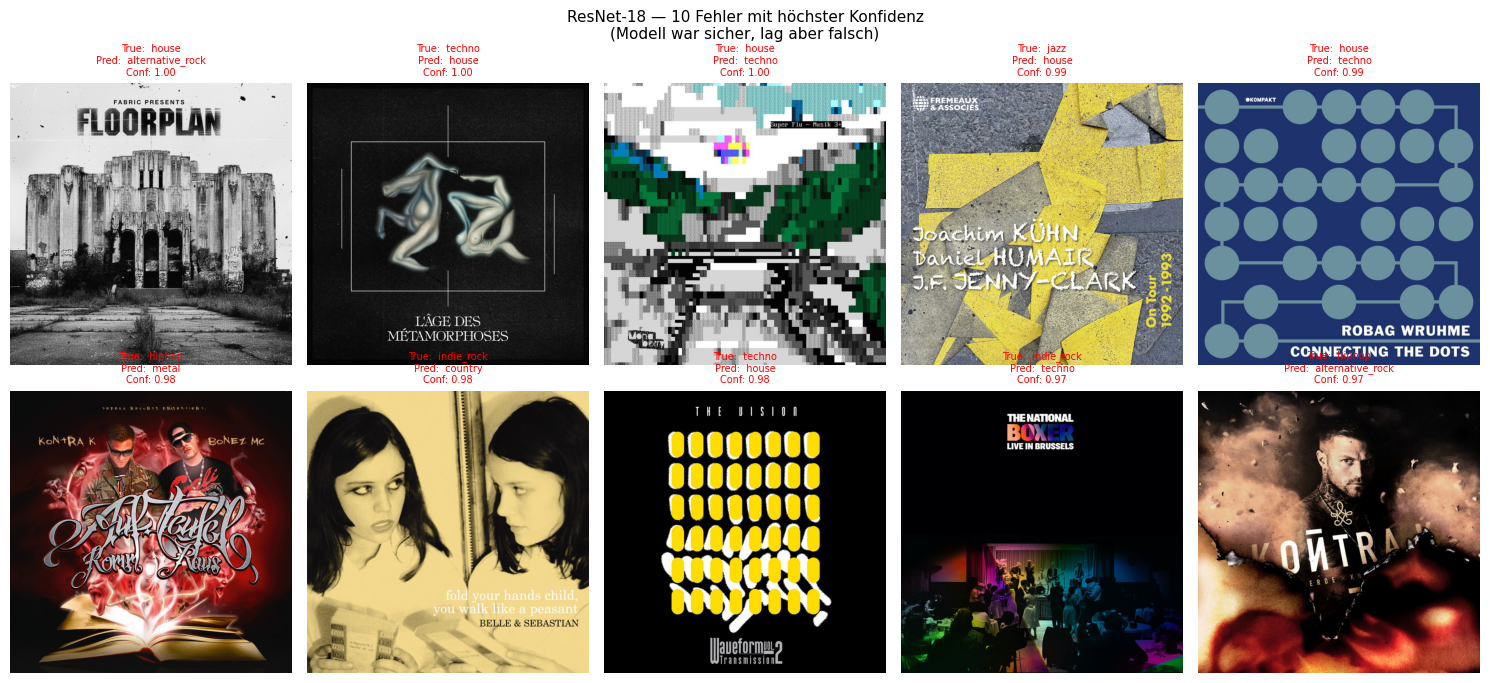


Gesamtzahl Fehler ResNet-18: 219 / 383


In [24]:
test_df = pd.read_csv(SPLITS_DIR / "test.csv")

errors = [
    (i, t, p, c)
    for i, (t, p, c) in enumerate(zip(resnet_true, resnet_pred, resnet_conf))
    if t != p
]

# Die 10 Fehler mit höchster Confidence zeigen (das Modell war sich "sicher", lag aber falsch)
errors_sorted = sorted(errors, key=lambda x: x[3], reverse=True)[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for ax, (idx, true_label, pred_label, conf) in zip(axes.flat, errors_sorted):
    cover_path = ROOT / test_df.iloc[idx]["cover_path"]  # relativ → absolut
    img = Image.open(cover_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(
        f"True:  {IDX_TO_GENRE[true_label]}\n"
        f"Pred:  {IDX_TO_GENRE[pred_label]}\n"
        f"Conf: {conf:.2f}",
        fontsize=7,
        color="red",
    )
    ax.axis("off")

plt.suptitle(
    "ResNet-18 — 10 Fehler mit höchster Konfidenz\n(Modell war sicher, lag aber falsch)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

print(f"\nGesamtzahl Fehler ResNet-18: {len(errors)} / {len(resnet_true)}")

## Diskussion

*(Diese Zelle nach dem Training mit konkreten Beobachtungen aus den obigen Plots ausfüllen.)*

**Erwartete Verwechslungen:**
- **Techno ↔ House:** Beide Genres teilen abstrakte, monochrome oder clubästhetische Cover-Designs. Die visuelle Grenze ist fließend, was selbst für menschliche Betrachter schwierig ist.
- **Jazz ↔ Classical:** Beide verwenden häufig schwarz-weiß Fotos, Portraits oder ornamentale Typografie.
- **Alternative Rock ↔ Indie Rock:** Als die stilistisch diversesten Genres sind beide schwer abzugrenzen.

**Modellvergleich:**
- ResNet-18 profitiert von pretrained ImageNet-Features: Texturen und Formen sind schon gelernt, die letzten Schichten müssen nur genre-spezifische Muster abstrahieren.
- Das Scratch CNN lernt von Null — bei 1 784 Trainingsbildern ist das eine starke Einschränkung. Der Train/Val-Gap (sichtbar in Notebook 04) zeigt Overfitting-Tendenzen trotz GAP + Dropout.
- Der Vergleich beider Modelle belegt empirisch den Mehrwert von Transfer Learning bei kleinen Datensätzen.